In [1]:
import librosa
import numpy

In [2]:
import os

In [3]:
from pathlib import Path

In [4]:
current_dir = Path().resolve()
base_dir= Path().resolve().parent
DATASET_PATH = base_dir/ "data" / "songs"
print(current_dir)
print(base_dir)
print(DATASET_PATH)

# path=os.getcwd()
# #dataset_path = os.path.join(path, 'data', 'songs')
# project_root=os.path.dirname(path)

# print(project_root)

dataset_path='C:/Users/PC/Desktop/project_CSE715_18101194_anika_ahsan/data/songs'
os.listdir(dataset_path)
# for i in dataset_path:
#     print(i)
#y,sr=librosa.load(dataset_path,sr=22050,duration=30)

C:\Users\PC\Desktop\project_CSE715_18101194_anika_ahsan\notebooks
C:\Users\PC\Desktop\project_CSE715_18101194_anika_ahsan
C:\Users\PC\Desktop\project_CSE715_18101194_anika_ahsan\data\songs


['Adele - Rolling in the Deep.mp3',
 'Amar Hiyar Majhe.mp3',
 'Amar Sadher Posha Pakhi.mp3',
 'Amaro Porano Jaha Chay.mp3',
 'Ami chini go chini tomare.mp3',
 'Amy Winehouse - Love Is A Losing Game.mp3',
 'Astrud Gilberto and Stan Getz - The Girl From Ipanema.mp3',
 'Billie Eilish - bad guy.mp3',
 'Billie Holiday - Strange Fruit.mp3',
 'Dariye Acho Tumi.mp3',
 'Deho Pakhi Uira Gele.mp3',
 'Dua Lipa - Levitating Feat. DaBaby (Lyrics).mp3',
 'Dua Lipa - New Rules.mp3',
 'dui diner ei duniya_baul.mp3',
 'Dukkhe Vora Jibon Amar.mp3',
 'Duniata Bhojbaji_baul.mp3',
 'Ed Sheeran - Shape of You.mp3',
 'Ei Kopaler Koto Ojon_baul.mp3',
 'Ektuku Choa Lage.mp3',
 'Emon Aghat Korli Re Bondhu.mp3',
 'Fifth Harmony - Work from Home.mp3',
 'Fly Me To The Moon.mp3',
 'Grover Washington Jr. - Just the Two of Us.mp3',
 'Jakhan Porbe Na Mor Payer Chinho.mp3',
 'Jonom Gelo Britha  Baul Gaan_baul.mp3',
 'Justin Bieber - Baby.mp3',
 'Justin Bieber - Let Me Love You.mp3',
 'Keu To Karo Na_baul.mp3',
 'Kotobar

In [5]:
dataset=os.listdir(DATASET_PATH)
len(os.listdir(DATASET_PATH))

60

In [ ]:
melspectrogram=[]
for data in dataset:
    song_path=os.path.join(DATASET_PATH,data)
    y,sr=librosa.load(song_path,duration=30)  # Load MP3 and automatically decode to waveform
    # print(y)
    # melspectrogram=librosa.feature.melspectrogram(y=y,sr=sr,n_mels=128)
    melspectrogram.append(librosa.feature.melspectrogram(y=y,sr=sr,n_mels=128))
    # print(melspectrogram.shape)
print(melspectrogram,'melspectrogram')

# Convert to log scale (VERY IMPORTANT)
mel_db=librosa.power_to_db(melspectrogram,ref=numpy.max)   
# print(mel_db.dtype)
print(mel_db.shape)

# Normalize 
mel_db = (mel_db - numpy.mean(mel_db)) / numpy.std(mel_db)
print(mel_db.shape)

[array([[0.0000000e+00, 0.0000000e+00, 2.2722055e-41, ..., 1.4837235e-01,
        1.1153816e-01, 1.5939657e-01],
       [0.0000000e+00, 0.0000000e+00, 5.3451129e-41, ..., 7.8523144e-02,
        8.5061960e-02, 4.8721308e-01],
       [0.0000000e+00, 0.0000000e+00, 7.0957550e-41, ..., 1.0134548e-01,
        4.9097782e-01, 1.2760096e+00],
       ...,
       [0.0000000e+00, 0.0000000e+00, 1.9057659e-43, ..., 1.9952029e-04,
        2.9906115e-04, 5.0159474e-04],
       [0.0000000e+00, 0.0000000e+00, 8.8281803e-44, ..., 1.5682852e-04,
        9.8346733e-05, 3.4017925e-04],
       [0.0000000e+00, 0.0000000e+00, 1.3172206e-43, ..., 9.8546261e-06,
        6.1958899e-06, 1.3983835e-04]], shape=(128, 1292), dtype=float32), array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        1.15115866e-01, 1.82272214e-02, 8.27206671e-03],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        2.70022810e-01, 5.82266562e-02, 1.09952450e-01],
       [0.00000000e+00, 0.00000000e+00, 0.0

In [73]:
# 2D-->1D
# Flatten each song separately
mel_flat= mel_db.reshape(mel_db.shape[0], -1)

# mel_flat = mel_db.flatten()
print(mel_flat )
print(mel_flat.shape )
# print(mel_flat.shape)


# features=[]
# features.append(mel_flat)
# X=numpy.array(features)
# print(X)
# print(X.shape )

input_dimension=mel_flat.shape[1]
print(input_dimension)


[[-1.4192072  -1.4192072  -1.4192072  ... -1.4192072  -1.4192072
  -1.2954316 ]
 [-1.4192072  -1.4192072  -1.4192072  ... -1.4192072  -1.4192072
  -1.1656176 ]
 [-1.4192072  -1.4192072  -1.4192072  ... -1.1931314  -0.6547387
  -0.48296243]
 ...
 [-1.4192072  -1.4192072  -1.4192072  ... -1.1770662  -1.2200683
  -0.8323768 ]
 [-1.4192072  -1.4192072  -1.4192072  ... -0.46010435 -0.40577143
  -0.35327083]
 [-1.4192072  -1.4192072  -1.0098273  ... -1.4192072  -1.4192072
  -1.4192072 ]]
(60, 165376)
165376


In [74]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader,TensorDataset
import matplotlib.pyplot as plt

In [75]:
#device
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [ ]:
#creating batches
BATCH_SIZE=15
print(mel_flat.shape)

#numpy array to tensor
dataset_tensor=torch.tensor(mel_flat, dtype=torch.float32)
dataset = TensorDataset(dataset_tensor)
train_dataset=DataLoader(dataset=dataset,
                         batch_size=BATCH_SIZE,
                         shuffle=True)

print(train_dataset)



###
# X_tensor = torch.tensor(X, dtype=torch.float32)
# dataset = TensorDataset(X_tensor)
# loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)



(60, 165376)


In [77]:
#VAE model
latent_dim=128
input_dimension=input_dimension

class VAE(nn.Module):
    def __init__(self,input_dim=input_dimension,hidden_dim=256,latent_dim=latent_dim):
        super().__init__()

        #encoder layers
        self.fully_connected_layer_1=nn.Linear(input_dim,512)
        self.fully_connected_layer_2=nn.Linear(512,256)
         
        #mean and log(variance) computation of encoder 
        self.mu=nn.Linear(256,latent_dim)
        self.logvar=nn.Linear(256,latent_dim)

        
        #decoder layers
        self.fully_connected_layer_3=nn.Linear(latent_dim,256)
        self.fully_connected_layer_4=nn.Linear(256,512)
        self.fully_connected_layer_5=nn.Linear(512,input_dim)



        #activation function
        self.relu=nn.ReLU()
        self.sigmoid=nn.Sigmoid()

    def encoder(self,x):
        hidden_layer_1=self.relu(self.fully_connected_layer_1(x))
        hidden_layer_2=self.relu(self.fully_connected_layer_2(hidden_layer_1))
        mu=self.mu(hidden_layer_2)
        logvar=self.logvar(hidden_layer_2)
        return mu,logvar

    def reparameterization(self,mu,logvar):
        standard_deviation=torch.exp(0.5*logvar)
        epsilon=torch.randn_like(standard_deviation)
        z=mu + epsilon*standard_deviation
        return z

    def decoder(self,z):
        hidden_layer_3=self.relu( self.fully_connected_layer_3(z))
        hidden_layer_4=self.relu(self.fully_connected_layer_4(hidden_layer_3))
        output=self.sigmoid(self.fully_connected_layer_5(hidden_layer_4))
        return output
        
    
    def forward(self,x):
        mu,logvar=self.encoder(x)  
        z=self.reparameterization(mu,logvar)
        x_reconstructed=self.decoder(z)
        return x_reconstructed, mu,logvar



In [81]:
#loss
def vae_loss(x_reconstructed,x,mu,logvar):
    reconstruction_loss=nn.functional.mse_loss(x_reconstructed,x)

    reconstruction_loss=nn.functional.mse_loss(x_reconstructed,x)

    # reconstruction_loss=nn.functional.binary_cross_entropy(x_reconstructed,x,reduction='sum')


    kl_loss=0.5*torch.sum(mu.pow(2) + logvar.exp() - logvar -1)

    return reconstruction_loss + kl_loss

In [82]:
model=VAE()  #creating object of class vae
optimizer=optim.Adam(model.parameters(),lr=1e-3)

In [ ]:
epochs=100

model.train()

for epoch in range(epochs):
    total_loss=0

    for (x,) in (train_dataset):
        
        x = x.to(device)
        # x = x.view(-1,input_dimension).to(device)
        # print(x.shape)
        optimizer.zero_grad()

        x_reconstructed,mu,logvar=model(x)  # x_reconstructed, mu, logvar = model.forward(x)
        loss=vae_loss( x_reconstructed,x,mu,logvar)

        loss.backward()
        optimizer.step()

        total_loss=total_loss + loss.item()

    avg_loss=total_loss/len(train_dataset.dataset)   


    print(f"epoch [{epoch+1}/{epochs},loss:{avg_loss:.4f}]")






epoch [0.01,loss:284.2681]
epoch [1.01,loss:277.4624]
epoch [2.01,loss:272.1537]
epoch [3.01,loss:269.4156]
epoch [4.01,loss:261.0164]
epoch [5.01,loss:257.1657]
epoch [6.01,loss:253.6461]
epoch [7.01,loss:247.4256]
epoch [8.01,loss:242.8996]
epoch [9.01,loss:238.3777]
epoch [10.01,loss:233.9517]
epoch [11.01,loss:228.5787]
epoch [12.01,loss:223.2092]
epoch [13.01,loss:219.0786]
epoch [14.01,loss:215.2096]
epoch [15.01,loss:211.1672]
epoch [16.01,loss:208.6322]
epoch [17.01,loss:205.9970]
epoch [18.01,loss:202.4583]
epoch [19.01,loss:199.0569]
epoch [20.01,loss:195.3018]
epoch [21.01,loss:192.2923]
epoch [22.01,loss:190.7184]
epoch [23.01,loss:188.1169]
epoch [24.01,loss:185.4080]
epoch [25.01,loss:184.4207]
epoch [26.01,loss:181.1835]
epoch [27.01,loss:177.3308]
epoch [28.01,loss:175.5105]
epoch [29.01,loss:172.3564]
epoch [30.01,loss:171.9647]
epoch [31.01,loss:168.5488]
epoch [32.01,loss:165.4237]
epoch [33.01,loss:162.7981]
epoch [34.01,loss:161.5351]
epoch [35.01,loss:158.3012]
ep

In [95]:
#latent features
model.eval()

latent_features=[]
with torch.no_grad():
     for (x,) in (train_dataset):
          x=x.to(device)
          x_reconstructed,mu,logvar=model(x)
          latent_features.append(mu.cpu().numpy())
          
print(latent_features)
latent_representation = numpy.vstack(latent_features)    
print(latent_representation)      

          
          


[array([[-0.2826641 , -0.04138551, -0.12474559, ..., -0.53309613,
        -0.59929603, -0.1810999 ],
       [ 0.28847283, -0.05099843, -0.27501523, ...,  0.17755729,
        -0.3664572 ,  0.2722116 ],
       [-0.1544214 , -0.08153068, -0.18386245, ..., -0.13890532,
        -0.4421671 ,  0.1378249 ],
       ...,
       [ 1.3583485 , -0.03398818,  0.8958791 , ..., -1.6943768 ,
        -1.8285266 ,  0.9984462 ],
       [-0.4088422 , -0.48366112,  0.44418865, ...,  0.6994103 ,
        -0.15217702, -0.5073645 ],
       [-0.17879285, -0.33124775, -0.0917148 , ...,  0.10105012,
         0.07451709, -0.04377387]], shape=(15, 128), dtype=float32), array([[ 0.7971622 , -0.04195626, -0.46840852, ...,  0.43959245,
        -0.867442  ,  0.53634536],
       [ 0.08595961,  0.01387711, -0.66905904, ..., -0.27125418,
        -0.08294742,  0.37726638],
       [ 0.5362614 , -0.0704702 ,  0.6572178 , ...,  0.06017613,
        -0.66972566,  0.1931967 ],
       ...,
       [-1.0819417 ,  0.6152206 ,  0.0168

In [91]:
# k means clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from matplotlib import pyplot


In [106]:
number_of_clusters=4

k_means=KMeans(n_clusters=number_of_clusters,random_state=42)
labels=k_means.fit_predict(latent_representation)
labels

array([0, 0, 0, 2, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 0, 3, 0, 0, 0, 0, 1, 0, 0, 1], dtype=int32)

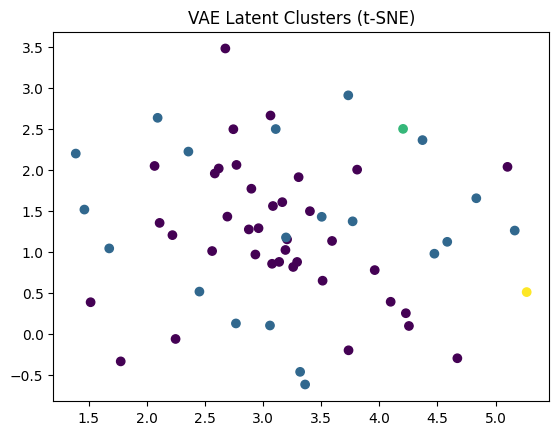

In [107]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30)
X_2d = tsne.fit_transform(latent_representation)

plt.scatter(X_2d[:,0], X_2d[:,1], c=labels)
plt.title("VAE Latent Clusters (t-SNE)")
plt.show()


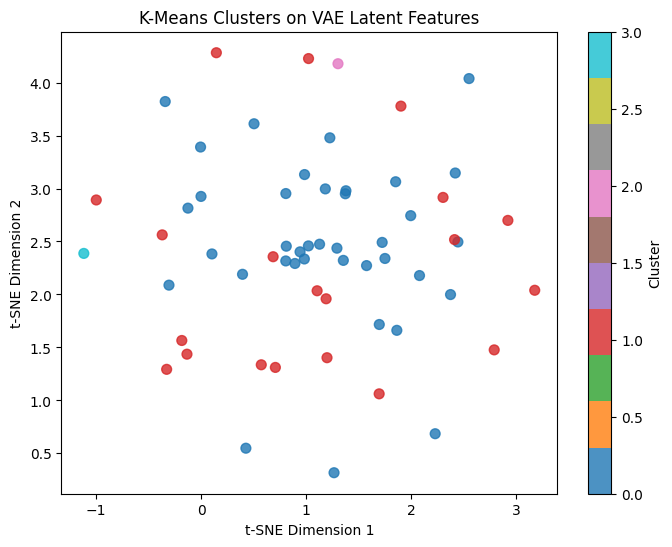

In [108]:
# Reduce latent vectors to 2D
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_tsne = tsne.fit_transform(latent_representation)

# Plot clusters
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=labels,
    cmap='tab10',
    s=50,
    alpha=0.8
)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("K-Means Clusters on VAE Latent Features")
plt.colorbar(scatter, label="Cluster")
plt.show()

In [109]:
# Baseline: PCA + K-Means
from sklearn.decomposition import PCA


pca = PCA(n_components=32)
X_pca = pca.fit_transform(mel_flat)


kmeans_pca = KMeans(n_clusters=4)
labels_pca = kmeans_pca.fit_predict(X_pca)




In [ ]:
# from sklearn.metrics import silhouette_score


# sil_vae = silhouette_score(latent_representation, labels)
# sil_pca = silhouette_score(X_pca, labels_pca)
# print(sil_vae,'sil_vae')
# print(sil_pca ,'sil_pca ')

0.05200826749205589 sil_vae
0.08369899541139603 sil_pca 


In [114]:
from sklearn.metrics import calinski_harabasz_score

ch_vae = calinski_harabasz_score(latent_representation, labels)
ch_pca = calinski_harabasz_score(X_pca, labels_pca)
print(ch_vae,'ch_vae')
print(ch_pca ,'ch_pca' )

2.6082420349121094 ch_vae
6.572338104248047 ch_pca
